In [19]:
"""
================================================================================
RESUME CONVERSION RATE ANALYSIS: A BAYESIAN APPROACH
================================================================================

EXECUTIVE SUMMARY
-----------------
This analysis evaluates the effectiveness of three different resume strategies applied sequentially
over a 3-month job hunting period. By using Bayesian Inference, we quantify the true effectiveness
of each strategy, filtering out noise and external factors (e.g., language barriers).

THE THREE STRATEGIES:
1. V1 (Original): The baseline resume.
2. V3 (Traditional Advice): Following standard career center advice (Safe Bet).
3. V2 (Hybrid Strategy): An optimized, user-centric approach (The Challenger).

KEY FINDINGS:
- **V2 is the clear winner**, achieving a conversion rate significantly higher than the market average.
- **The "Lag Effect" is real**: V2 appeared to fail initially due to slow recruiter response times,
  leading to a "Panic Switch" to V3. Data proves this switch was premature.
- **Traditional Advice (V3) performed poorly**, statistically indistinguishable from the baseline (V1).

--------------------------------------------------------------------------------
TABLE OF CONTENTS
-----------------
PART 0: Global Configuration & Data Setup
PART 1: Prior Predictive Simulation (Establishing the Baseline)
PART 2: Model Fitting (Bayesian Updating with Adjusted Data)
PART 3: Posterior Predictive Simulation (Projecting Future Outcomes)
PART 4: KDE Plot (Comparing True Skill Distributions)
PART 5: Inference (Probabilistic Questions & Answers)
PART 6: Forest Plot & Difference Plot (Decision Making)
PART 7: Timeline Step Plot (Time-Based)
PART 8: Bar Chart (Raw vs Adjusted)
PART 9: Sensitivity Analysis (Pessimistic Prior)
PART 10: Statistical Validation (Robustness Check)
PART 11: The "Alpha" Analysis (Risk-Adjusted Performance)
PART 12: Final Verdict
================================================================================
"""

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from matplotlib.ticker import PercentFormatter

# ==========================================
# 0. GLOBAL CONFIGURATION (Single Source of Truth)
# ==========================================
# Set seed for reproducibility
np.random.seed(222)

# Global Constants
MARKET_BASELINE = 0.02  # 2% Market Average for non-native speakers
TARGET_RATE = 0.10      # 10% Target Conversion Rate

COLORS = {
    'V1': '#95a5a6',  # Cool Grey
    'V2': '#ff6b6b',  # Coral Red
    'V3': '#2980b9',  # Strong Blue
    'Market': '#f39c12', # Orange
    'Target': '#27ae60', # Green
    'Panic': '#ff6b6b'   # Same as V2
}

# Define data and visualization parameters for all strategies
# Note: 'german_req' is determined EX-ANTE from the job posting itself
# (role explicitly states German proficiency is required AND the JD is written in German),
# independent of any interview outcome. This avoids selection bias from filtering on rejections.
strategies = {
    "V1": {
        "label": "V1: Original (Baseline)",
        "short_label": "V1 (Original)",
        "n": 23, "k": 0, "german_req": 2,  # 23 apps, 0 interviews, 2 German roles
        "color": COLORS['V1']
    },
    "V3": {
        "label": "V3: Traditional Advice (Safe Bet)",
        "short_label": "V3 (Traditional Advice)",
        "n": 15, "k": 0, "german_req": 1,  # 15 apps, 0 interviews, 1 German role
        "color": COLORS['V3']
    },
    "V2": {
        "label": "V2: Hybrid Strategy (Optimized)",
        "short_label": "V2 (Hybrid Strategy)",
        "n": 20, "k": 5, "german_req": 6,  # 20 apps, 5 interviews, 6 German roles
        "color": COLORS['V2']
    }
}

# Define plot order (logical flow: Baseline -> Traditional Advice -> Optimized)
plot_order = ["V1", "V3", "V2"]

print("Global Data Configuration Loaded.")
print("NOTE: Bayesian Inference will use ADJUSTED data (excluding German roles) to evaluate true resume skill.")
for key in plot_order:
    s = strategies[key]
    valid_n = s['n'] - s['german_req']
    print(f"{key}: Raw N={s['n']} -> Valid N={valid_n}, Success={s['k']}")


Global Data Configuration Loaded.
NOTE: Bayesian Inference will use ADJUSTED data (excluding German roles) to evaluate true resume skill.
V1: Raw N=23 -> Valid N=21, Success=0
V3: Raw N=15 -> Valid N=14, Success=0
V2: Raw N=20 -> Valid N=14, Success=5


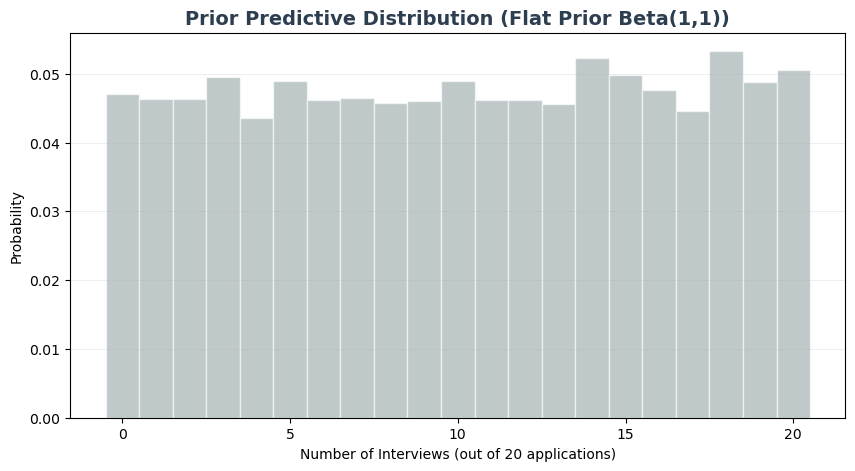

In [20]:
# ==========================================
# PART 1: Prior Predictive Simulation (Flat Prior)
# ==========================================
"""
Objective: Visualize our starting assumption (Prior).
Assumption: Flat Prior Beta(1,1).
Meaning: Before seeing any data, we assume any conversion rate (0% to 100%) is equally possible.
This represents a state of "total ignorance" or "unbiasedness".
"""
n_sims = 10000
prior_alpha, prior_beta = 1, 1

# 1. Draw samples from the prior distribution
prior_samples = stats.beta(prior_alpha, prior_beta).rvs(n_sims)

# 2. Simulate potential outcomes for a typical batch of 20 applications
# If the prior is true, what distribution of interview counts would we expect?
sim_interviews = stats.binom(n=20, p=prior_samples).rvs(n_sims)

# Visualization
plt.figure(figsize=(10, 5))
plt.hist(sim_interviews, bins=np.arange(-0.5, 21.5, 1), density=True,
         color=COLORS['V1'], edgecolor='white', alpha=0.6) # Use V1 color for neutral prior
plt.title("Prior Predictive Distribution (Flat Prior Beta(1,1))", fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel("Number of Interviews (out of 20 applications)")
plt.ylabel("Probability")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [21]:
# ==========================================
# PART 2: Model Fitting (Using ADJUSTED Data)
# ==========================================
"""
Objective: Update our beliefs using observed data (Bayesian Inference).
Method: Beta-Binomial Conjugate Update.
    Posterior Alpha = Prior Alpha + Successes
    Posterior Beta  = Prior Beta + Failures
Data Used: Adjusted Data (Valid N = Total N - German Roles).
Reason: We want to measure the effectiveness of the resume content itself, excluding external
factors like language mismatch which are independent of resume quality.
"""
n_samples = 100000

print("Updating Beliefs (Bayesian Inference) using ADJUSTED Data:")
print("-" * 50)

for key, data in strategies.items():
    # Calculate valid sample size (excluding German roles)
    valid_n = data['n'] - data['german_req']
    successes = data['k']

    # Sanity check: all observed interviews must lie within the valid (non-German) subset.
    # Guards against future data-entry errors that could silently break the posterior.
    assert successes <= valid_n, (
        f"{key}: successes ({successes}) > valid_n ({valid_n}) — "
        f"check german_req filter for outcome leakage"
    )

    # Update Rule
    post_alpha = prior_alpha + successes
    post_beta = prior_beta + (valid_n - successes)

    # Create frozen distribution object for later use
    dist = stats.beta(post_alpha, post_beta)

    # Store distribution, parameters, and samples in the strategies dictionary
    data['posterior_dist'] = dist
    data['post_alpha'] = post_alpha
    data['post_beta'] = post_beta
    data['samples'] = dist.rvs(n_samples)

    print(f"[{key}] Valid Apps: {successes}/{valid_n} -> Posterior: Beta({post_alpha}, {post_beta})")

print("-" * 50)
print("Model fitting complete. Samples generated based on English-friendly roles only.")


Updating Beliefs (Bayesian Inference) using ADJUSTED Data:
--------------------------------------------------
[V1] Valid Apps: 0/21 -> Posterior: Beta(1, 22)
[V3] Valid Apps: 0/14 -> Posterior: Beta(1, 15)
[V2] Valid Apps: 5/14 -> Posterior: Beta(6, 10)
--------------------------------------------------
Model fitting complete. Samples generated based on English-friendly roles only.


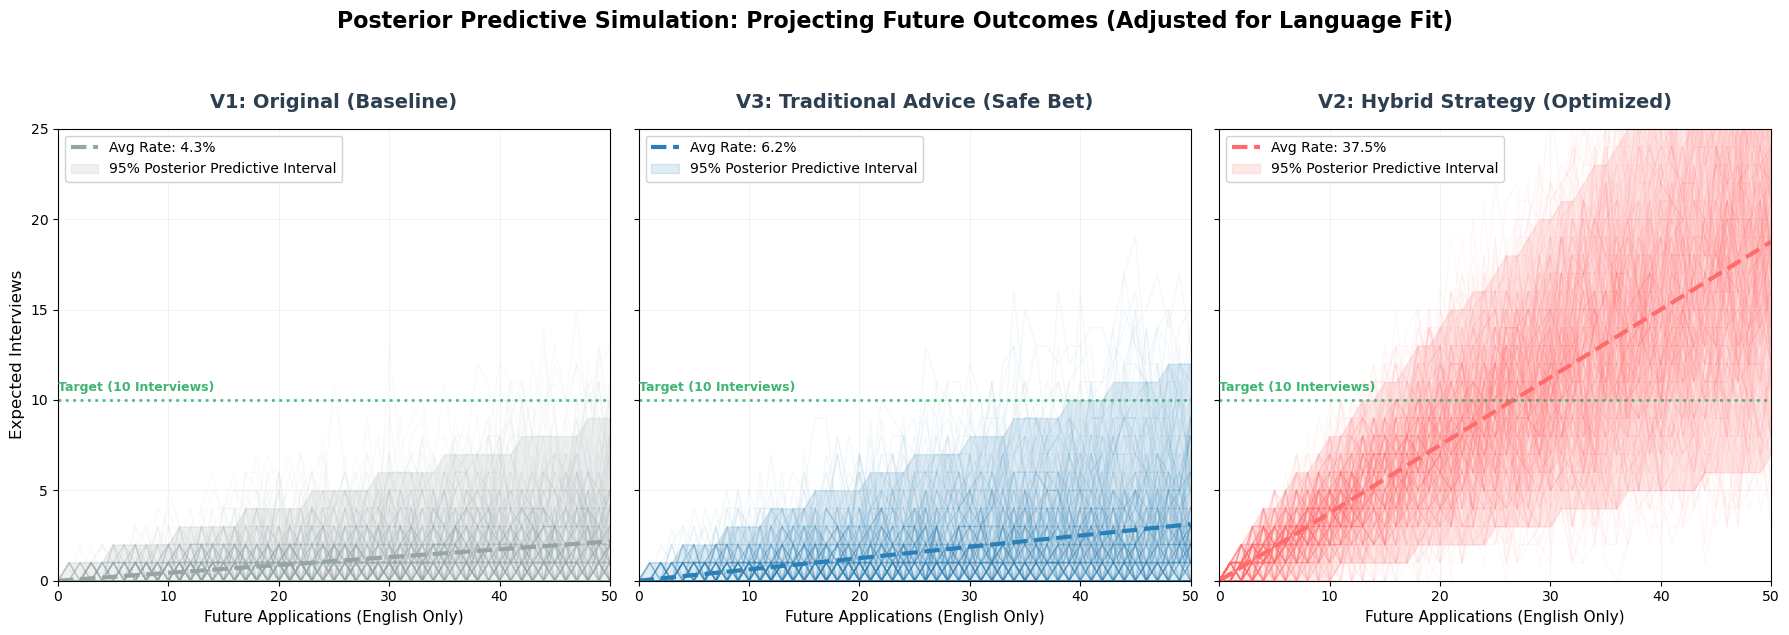

In [22]:
# ==========================================
# PART 3: Posterior Predictive Simulation (The "Noodle" Plot)
# ==========================================
"""
Objective: Visualize the FULL uncertainty of future outcomes.
Plot: Posterior Predictive Simulation. Each line is a Binomial draw from a rate
      sampled from the posterior Beta distribution, so the spread reflects BOTH:
      (1) epistemic uncertainty about the true underlying rate, and
      (2) aleatoric (Binomial sampling) noise in actual interview counts.
      The shaded band is the analytical 95% Beta-Binomial predictive interval.
Interpretation:
- Line spread is wider than a rate-only view — this is the honest predictive range.
- V1/V3 trajectories cluster near zero.
- V2 trends upward with a wide but strictly positive predictive band.
"""
# Use integer application counts so Binomial sampling is well-defined
x_future = np.arange(0, 51)   # 0 to 50 future applications (integer)
n_lines = 300                 # Number of predictive trajectories to draw

# Reproducible RNG so re-running this cell alone gives the same result
rng_part3 = np.random.default_rng(222)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, key in zip(axes, plot_order):
    data = strategies[key]
    a_post = data['post_alpha']
    b_post = data['post_beta']
    color = data['color']

    # A. TRUE posterior predictive:
    #    For each rate drawn from the posterior, simulate actual interview counts
    #    via Binomial sampling. This captures BOTH epistemic (rate) and
    #    aleatoric (sampling) uncertainty.
    simulated_rates = stats.beta(a_post, b_post).rvs(n_lines, random_state=rng_part3)
    for rate in simulated_rates:
        y_actual = rng_part3.binomial(x_future, rate)
        ax.plot(x_future, y_actual, color=color, alpha=0.05, linewidth=1.0)

    # B. Expected trajectory (posterior mean rate × n)
    mean_rate = a_post / (a_post + b_post)
    ax.plot(x_future, mean_rate * x_future, color=color, linewidth=3, linestyle='--',
            label=f"Avg Rate: {mean_rate:.1%}")

    # C. Analytical 95% Posterior Predictive Interval.
    #    The marginal distribution of interview counts is Beta-Binomial(n, a_post, b_post).
    pp_lower = stats.betabinom.ppf(0.025, x_future, a_post, b_post)
    pp_upper = stats.betabinom.ppf(0.975, x_future, a_post, b_post)
    ax.fill_between(x_future, pp_lower, pp_upper,
                    color=color, alpha=0.15, label="95% Posterior Predictive Interval")

    # Settings
    ax.set_title(data['label'], fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_xlabel("Future Applications (English Only)", fontsize=11)
    if key == plot_order[0]:
        ax.set_ylabel("Expected Interviews", fontsize=12)

    # Target Line (e.g., 10 interviews)
    ax.axhline(10, color=COLORS['Target'], linestyle=':', linewidth=2, alpha=0.8)
    ax.text(0, 10.5, "Target (10 Interviews)", color=COLORS['Target'], fontsize=9, fontweight='bold', alpha=0.9)

    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 25)

plt.suptitle("Posterior Predictive Simulation: Projecting Future Outcomes (Adjusted for Language Fit)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


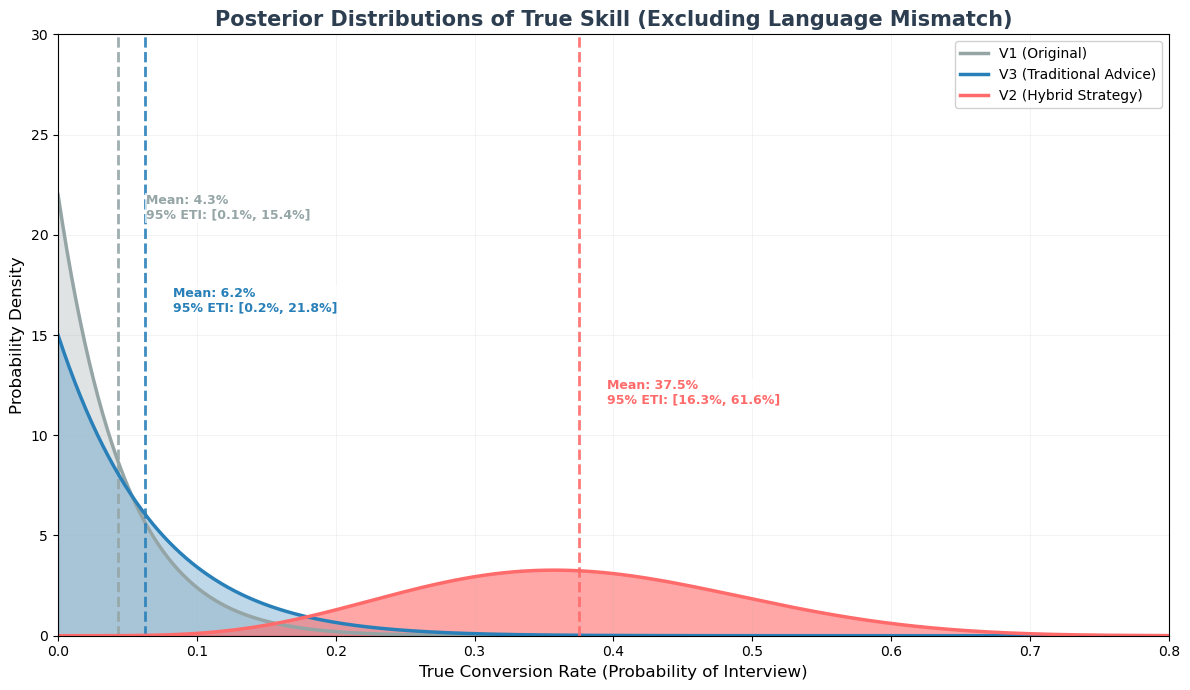

In [23]:
# ==========================================
# PART 4: KDE Plot (Mean vs Peak)
# ==========================================
"""
Objective: Compare the full posterior distributions of the true conversion rate.
Key Insight:
- Mean (Expected Value): the posterior mean of the true rate for each strategy.
- 95% CI: the range where the true rate lies with 95% posterior probability.
- V2's distribution is clearly separated from V1 and V3.
Note: Mode is intentionally omitted. For V1/V3 (k=0) the true posterior mode is at 0;
      any KDE-based "peak" would be a bandwidth artifact, not a meaningful statistic.
"""
plt.figure(figsize=(12, 7))

# Analytical Beta PDF grid — matches the Streamlit app's rendering exactly.
# Using the closed-form PDF avoids KDE bandwidth artifacts near x=0 that
# otherwise exaggerate V1/V3 (both have α=1, so their true PDFs have finite
# but steep peaks at the origin). See Part 9 note on the same issue.
x_grid = np.linspace(0, 0.80, 1000)

# Fix y-limits BEFORE the loop so text positions are consistent
Y_MAX = 30
plt.ylim(0, Y_MAX)

for key in plot_order:
    data = strategies[key]
    color = data['color']

    # Posterior parameters (flat Beta(1,1) prior + observed data)
    a_post = data['post_alpha']
    b_post = data['post_beta']
    dist = stats.beta(a_post, b_post)

    # 1. Plot analytical Beta PDF (exact, no bandwidth parameter)
    pdf_y = dist.pdf(x_grid)
    plt.plot(x_grid, pdf_y, color=color, linewidth=2.5, label=data['short_label'])
    plt.fill_between(x_grid, pdf_y, color=color,
                     alpha=0.3 if key != 'V2' else 0.6)

    # 2. Stats: posterior mean + 95% equal-tailed credible interval
    # (computed analytically from the distribution, not from MC samples)
    avg = dist.mean()
    ci_lo, ci_hi = dist.ppf([0.025, 0.975])

    # 3. Plot vertical line for mean
    plt.axvline(avg, color=color, linestyle='--', linewidth=2, alpha=0.9)

    # 4. Annotate text (staggered height to avoid overlap)
    if key == 'V1':
        y_pos_factor = 0.90
    elif key == 'V3':
        y_pos_factor = 0.70
    else:
        y_pos_factor = 0.50

    y_pos = Y_MAX * y_pos_factor

    plt.text(avg + 0.02, y_pos,
             f"Mean: {avg:.1%}\n95% ETI: [{ci_lo:.1%}, {ci_hi:.1%}]",
             color=color, fontweight='bold', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title("Posterior Distributions of True Skill (Excluding Language Mismatch)",
          fontsize=15, fontweight='bold', color='#2c3e50')
plt.xlabel("True Conversion Rate (Probability of Interview)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.xlim(0, 0.80)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [24]:
# ==========================================
# PART 5: Inference (Probability Queries)
# ==========================================
"""
Objective: Answer direct business questions using probability.
Questions:
a) Is V2 better than V3? (Optimized vs Traditional Advice)
b) Is V3 better than V1? (Traditional Advice vs Doing Nothing)
c) What is the reliable range for V2's performance?
"""
samples_v1 = strategies['V1']['samples']
samples_v2 = strategies['V2']['samples']
samples_v3 = strategies['V3']['samples']

# a) V2 > V3?
prob_v2_better_v3 = np.mean(samples_v2 > samples_v3)

# b) V3 > V1?
prob_v3_better_v1 = np.mean(samples_v3 > samples_v1)

# c) V2 Credible Interval
ci_v2 = np.percentile(samples_v2, [2.5, 97.5])

print(f"Inference Results (Based on Adjusted Data):")
print(f"a) Probability that V2 > V3: {prob_v2_better_v3:.4%}")
print(f"b) Probability that V3 > V1: {prob_v3_better_v1:.4%}")
print(f"c) 95% Credible Interval for V2: [{ci_v2[0]:.1%} - {ci_v2[1]:.1%}]")


Inference Results (Based on Adjusted Data):
a) Probability that V2 > V3: 99.1840%
b) Probability that V3 > V1: 59.5930%
c) 95% Credible Interval for V2: [16.3% - 61.6%]


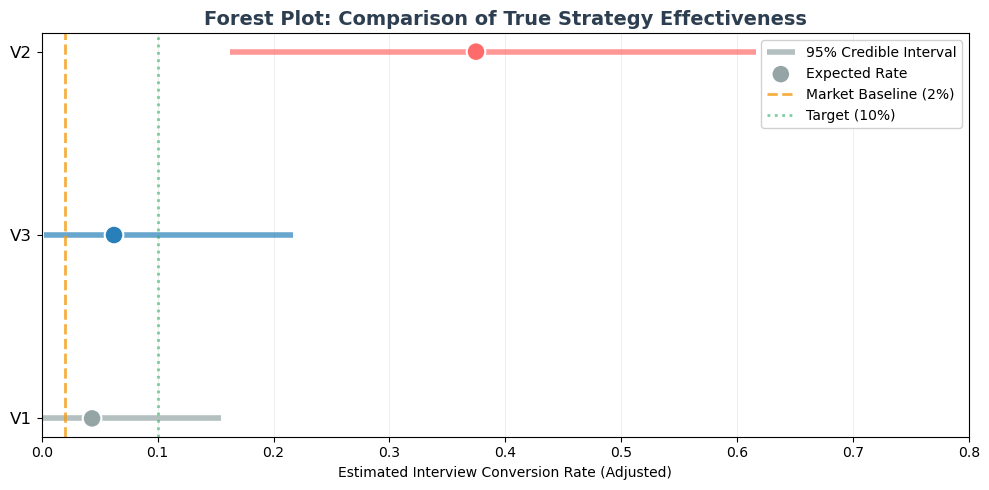

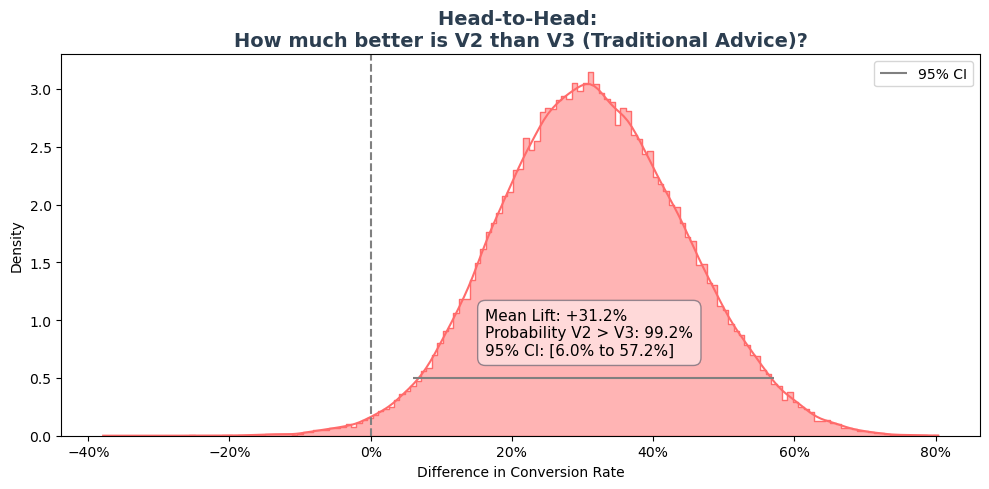

In [25]:
# ==========================================
# PART 6: Forest Plot & Difference Plot
# ==========================================
"""
Objective: Summarize the comparison in a decision-ready format.
Chart A (Forest Plot): Shows the Credible Intervals vs Market Baseline.
    - If the interval is entirely to the right of the baseline, the strategy is significantly effective.
Chart B (Difference Plot): Shows the distribution of (V2 - V3).
    - Quantifies the "Lift" or improvement.
Key Insight:
- Chart A (Forest Plot) reveals that V2 is the ONLY strategy where the 95% Credible Interval sits entirely above the Market Baseline (2%).
- Chart B (Difference Plot) confirms a positive "Lift" with >99% probability, visually ruling out V3 as a superior option.
"""
# Chart A: Forest Plot
plt.figure(figsize=(10, 5))

means = []
ci_lower = []
ci_upper = []
colors = []
labels = []

for key in plot_order:
    data = strategies[key]
    samples = data['samples']

    means.append(np.mean(samples))
    # Consistent 95% CI
    ci = np.percentile(samples, [2.5, 97.5])
    ci_lower.append(ci[0])
    ci_upper.append(ci[1])
    colors.append(data['color'])
    labels.append(key)

y_pos = np.arange(len(labels))
plt.hlines(y_pos, ci_lower, ci_upper, color=colors, linewidth=4, alpha=0.7, label='95% Credible Interval')
plt.scatter(means, y_pos, color=colors, s=180, zorder=3, edgecolors='white', linewidth=1.5, label='Expected Rate')

plt.yticks(y_pos, labels, fontsize=12)
plt.xlabel("Estimated Interview Conversion Rate (Adjusted)")
plt.title("Forest Plot: Comparison of True Strategy Effectiveness", fontsize=14, fontweight='bold', color='#2c3e50')

# Add Market Baseline (2%) and Target (10%)
plt.axvline(0.02, color=COLORS['Market'], linestyle='--', linewidth=2, alpha=0.8, label='Market Baseline (2%)')
plt.axvline(0.10, color=COLORS['Target'], linestyle=':', linewidth=2, alpha=0.6, label='Target (10%)')

plt.xlim(0, 0.8)
plt.grid(axis='x', alpha=0.3)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# Chart B: Difference Plot (V2 - V3)
diff_v2_v3 = samples_v2 - samples_v3
prob_positive = np.mean(diff_v2_v3 > 0)
mean_diff = np.mean(diff_v2_v3)
ci_diff = np.percentile(diff_v2_v3, [2.5, 97.5])

plt.figure(figsize=(10, 5))
# Use V2 color for difference plot to show "V2's Gain"
sns.histplot(diff_v2_v3, kde=True, color=COLORS['V2'], alpha=0.5, stat='density', element="step")
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

plt.hlines(y=0.5, xmin=ci_diff[0], xmax=ci_diff[1], color='gray', linewidth=1.5, label='95% CI')

# Add Statistics Box (Moved to left of 0.0 to avoid overlap)
stats_text = (
    f"Mean Lift: +{mean_diff:.1%}\n"
    f"Probability V2 > V3: {prob_positive:.1%}\n"
    f"95% CI: [{ci_diff[0]:.1%} to {ci_diff[1]:.1%}]"
)
# Position text at x=-0.15 (left side)
plt.text(mean_diff-0.15, 0.7, stats_text, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='#2c3e50', boxstyle='round,pad=0.5'))

plt.title(f"Head-to-Head: \nHow much better is V2 than V3 (Traditional Advice)?", fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel("Difference in Conversion Rate")
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.legend()
plt.tight_layout()
plt.show()

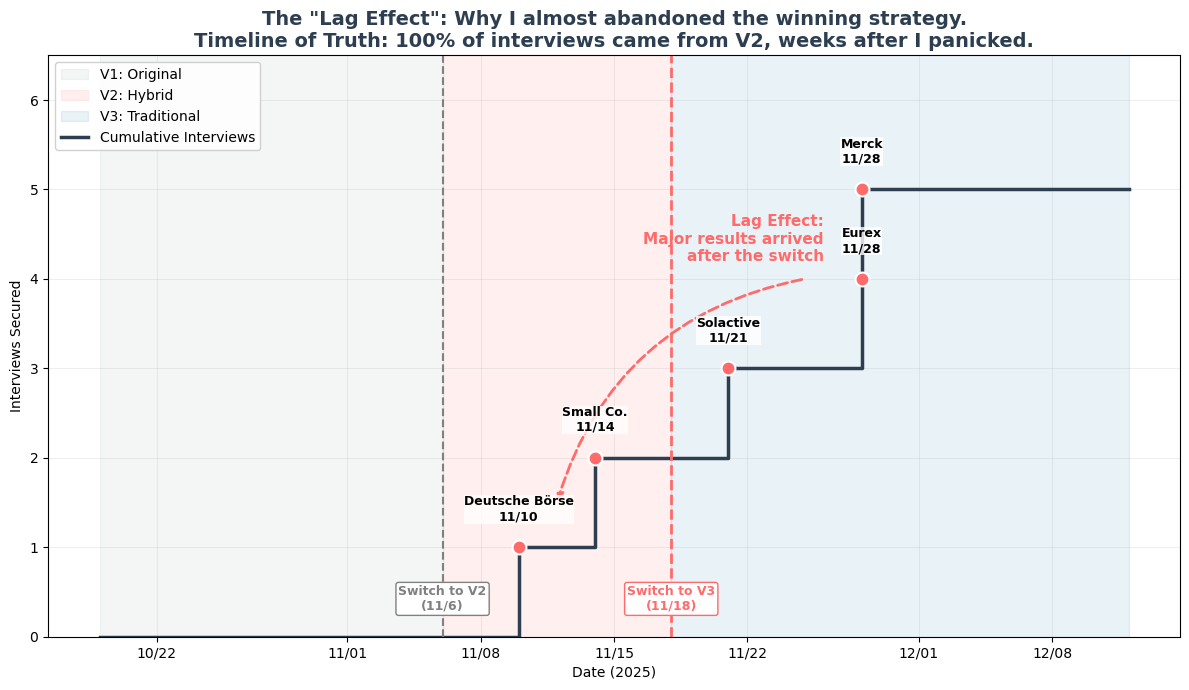

In [26]:
# ==========================================
# PART 7: Timeline Step Plot (Time-Based)
# ==========================================
"""
Objective: Visualize the "Lag Effect" and the "Panic Switch" using REAL DATES.
Data: Real interview dates vs. Application periods.
Key Insight: The "Panic Switch" to V3 happened on Nov 18, when only 2 interviews had arrived.
             The major V2 results (3 big interviews) arrived AFTER the switch.
"""
# 1. Setup Data
# Periods
d_start = datetime(2025, 10, 19)
d_v2 = datetime(2025, 11, 6)
d_v3 = datetime(2025, 11, 18) # Panic Switch
d_end = datetime(2025, 12, 12)

# Interviews (Real Dates)
# Note: Eurex and Merck are on the same day (11/28)
events = [
    {"date": datetime(2025, 11, 10), "company": "Deutsche Börse"},
    {"date": datetime(2025, 11, 14), "company": "Small Co."},
    {"date": datetime(2025, 11, 21), "company": "Solactive"},
    {"date": datetime(2025, 11, 28), "company": "Eurex"},
    {"date": datetime(2025, 11, 28), "company": "Merck"},
]
# Sort by date
events.sort(key=lambda x: x['date'])

# Build Step Data
x_dates = [d_start]
y_counts = [0]
curr = 0

for e in events:
    x_dates.append(e['date'])
    y_counts.append(curr) # Step
    curr += 1
    x_dates.append(e['date'])
    y_counts.append(curr) # Jump

x_dates.append(d_end)
y_counts.append(curr)

# 2. Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Backgrounds (Updated Colors)
ax.axvspan(d_start, d_v2, color=strategies['V1']['color'], alpha=0.1, label='V1: Original')
ax.axvspan(d_v2, d_v3, color=strategies['V2']['color'], alpha=0.1, label='V2: Hybrid')
ax.axvspan(d_v3, d_end, color=strategies['V3']['color'], alpha=0.1, label='V3: Traditional')

# Step Line
ax.step(x_dates, y_counts, where='post', color='#2c3e50', linewidth=2.5, label='Cumulative Interviews')

# Switch to V2
ax.axvline(d_v2, color='gray', linestyle='--')
ax.text(d_v2, 0.3, "Switch to V2\n(11/6)", ha='center', fontsize=9, color='gray', fontweight='bold',
         bbox=dict(fc='white', ec='gray', boxstyle='round,pad=0.2'))

# Panic Line (Switch to V3)
ax.axvline(d_v3, color=COLORS['Panic'], linestyle='--', linewidth=2)
ax.text(d_v3, 0.3, "Switch to V3\n(11/18)", ha='center', fontsize=9, color=COLORS['Panic'], fontweight='bold',
        bbox=dict(fc='white', ec=COLORS['Panic'], boxstyle='round,pad=0.2'))

# Lag Arrow (Updated Color)
# From ~Nov 25 (Results) back to ~Nov 12 (V2 Action)
# Moved text to the left (11/23) to avoid overlap
ax.annotate("",
            xy=(mdates.date2num(datetime(2025, 11, 12)), 1.5),
            xytext=(mdates.date2num(datetime(2025, 11, 25)), 4),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.3", color=COLORS['Panic'], lw=2, ls='--'))
ax.text(datetime(2025, 11, 26), 4.2, "Lag Effect:\nMajor results arrived\nafter the switch",
        color=COLORS['Panic'], fontsize=11, fontweight='bold', ha='right')

# Points & Labels
for e in events:
    d = e['date']
    # Find y value after jump
    y_val = events.index(e) + 1

    offset_y = 0.3

    ax.scatter(d, y_val, color=COLORS['V2'], s=100, zorder=10, edgecolor='white', linewidth=1.5)

    label = f"{e['company']}\n{d.strftime('%m/%d')}"
    ax.text(d, y_val + offset_y, label, ha='center', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.2))

# Format
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.set_title('The "Lag Effect": Why I almost abandoned the winning strategy.\nTimeline of Truth: 100% of interviews came from V2, weeks after I panicked.', fontsize=14, fontweight='bold', color='#2c3e50')
ax.set_ylabel("Interviews Secured")
ax.set_xlabel("Date (2025)")
ax.set_ylim(0, 6.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()


V1: Valid Apps=21, Adj Rate=0.0%, 95% CI=[0.0%, 16.1%]
V3: Valid Apps=14, Adj Rate=0.0%, 95% CI=[0.0%, 23.2%]
V2: Valid Apps=14, Adj Rate=35.7%, 95% CI=[12.8%, 64.9%]


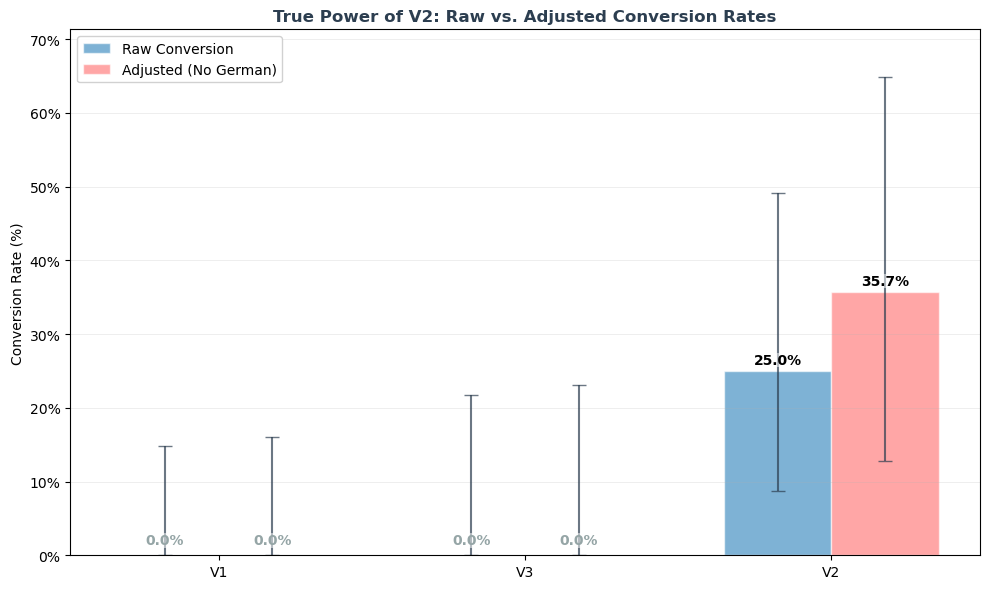

In [27]:
# ==========================================
# PART 8: Bar Chart (Raw vs Adjusted)
# ==========================================
"""
Objective: Compare Raw Conversion Rates vs Adjusted Conversion Rates.
Insight: V2's raw rate is already good, but the adjusted rate (excluding German roles) reveals its true power.
"""
labels_list = []
raw_rates = []
adj_rates = []
raw_err_lo, raw_err_hi = [], []
adj_err_lo, adj_err_hi = [], []

for key in plot_order:
    data = strategies[key]
    n, k = data['n'], data['k']
    valid_apps = n - data['german_req']

    # Point estimates
    raw = k / n
    adj = k / valid_apps if valid_apps > 0 else 0

    # 95% CI via Clopper-Pearson exact interval.
    # Anchored at the empirical rate k/n, so error bars are always non-negative.
    # For k=0: lower bound = 0; for k=n: upper bound = 1.
    def clopper_pearson(k_, n_, alpha=0.05):
        lo = 0.0 if k_ == 0 else stats.beta.ppf(alpha / 2, k_, n_ - k_ + 1)
        hi = 1.0 if k_ == n_ else stats.beta.ppf(1 - alpha / 2, k_ + 1, n_ - k_)
        return lo, hi

    raw_lo, raw_hi = clopper_pearson(k, n)
    adj_lo, adj_hi = clopper_pearson(k, valid_apps)

    labels_list.append(key)
    raw_rates.append(raw * 100)
    adj_rates.append(adj * 100)
    raw_err_lo.append((raw - raw_lo) * 100)
    raw_err_hi.append((raw_hi - raw) * 100)
    adj_err_lo.append((adj - adj_lo) * 100)
    adj_err_hi.append((adj_hi - adj) * 100)

    print(f"{key}: Valid Apps={valid_apps}, Adj Rate={adj:.1%}, "
          f"95% CI=[{adj_lo:.1%}, {adj_hi:.1%}]")

x = np.arange(len(labels_list))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, raw_rates, width,
                yerr=[raw_err_lo, raw_err_hi], capsize=5,
                label='Raw Conversion', color=COLORS['V3'], alpha=0.6,
                edgecolor='white', linewidth=1,
                error_kw={'alpha': 0.7, 'ecolor': '#2c3e50'})
bars2 = plt.bar(x + width/2, adj_rates, width,
                yerr=[adj_err_lo, adj_err_hi], capsize=5,
                label='Adjusted (No German)', color=COLORS['V2'], alpha=0.6,
                edgecolor='white', linewidth=1,
                error_kw={'alpha': 0.7, 'ecolor': '#2c3e50'})

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        # Force label even if height is 0
        label_val = f'{height:.1f}%'

        # Adjust text color based on bar color for better contrast
        text_color = 'black' if height > 0 else COLORS['V1'] # Darker for non-zero, V1 color for zero

        # If height is 0, place label slightly above 0 with a background box
        y_pos = height if height > 0 else 0.5

        plt.annotate(label_val, xy=(bar.get_x() + bar.get_width()/2, y_pos),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom',
                     fontweight='bold', color=text_color,
                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.1)) # Added subtle background

add_labels(bars1)
add_labels(bars2)

plt.ylabel('Conversion Rate (%)')
plt.title('True Power of V2: Raw vs. Adjusted Conversion Rates', fontweight='bold', color='#2c3e50')
plt.xticks(x, labels_list)
plt.gca().yaxis.set_major_formatter(PercentFormatter()) # Format Y-axis as percentage
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
# Leave headroom for the upper error bars
max_upper = max(
    [r + e for r, e in zip(raw_rates, raw_err_hi)] +
    [a + e for a, e in zip(adj_rates, adj_err_hi)]
)
plt.ylim(0, max_upper * 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



SENSITIVITY ANALYSIS: PESSIMISTIC PRIOR Beta(1, 50)
Assumption: 'A prior state of 1 success and 50 failures'


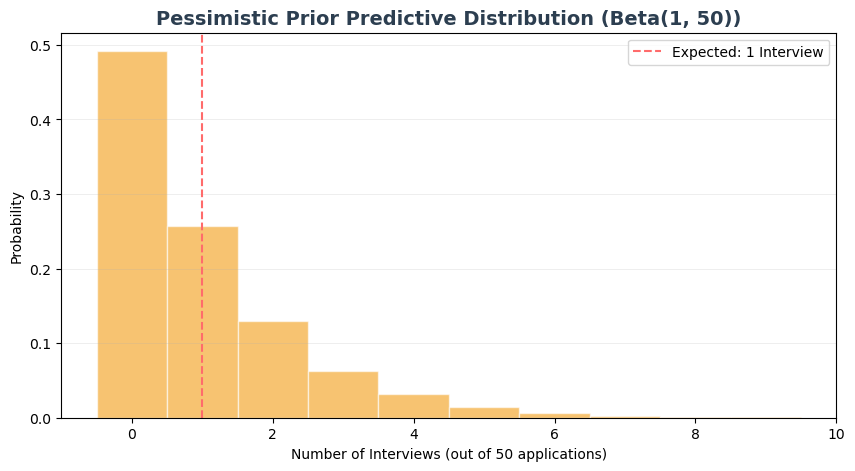

[V1] Posterior: Beta(1, 71) -> Mean: 1.4%
[V3] Posterior: Beta(1, 64) -> Mean: 1.5%
[V2] Posterior: Beta(6, 59) -> Mean: 9.2%
------------------------------
Even with a Pessimistic Prior:
a) Probability that V2 > V3: 98.6410%
b) 95% Credible Interval for V2: [3.6% - 17.3%]


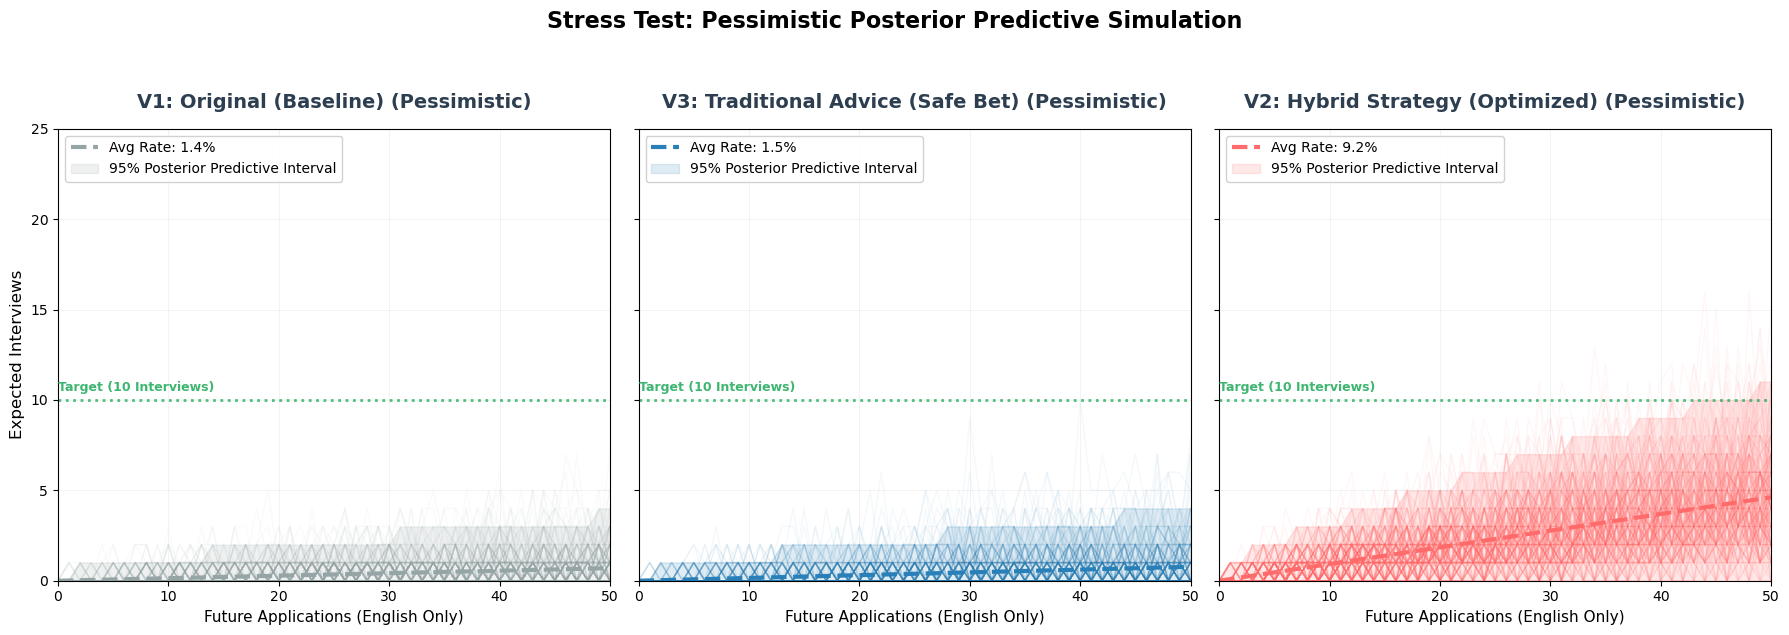

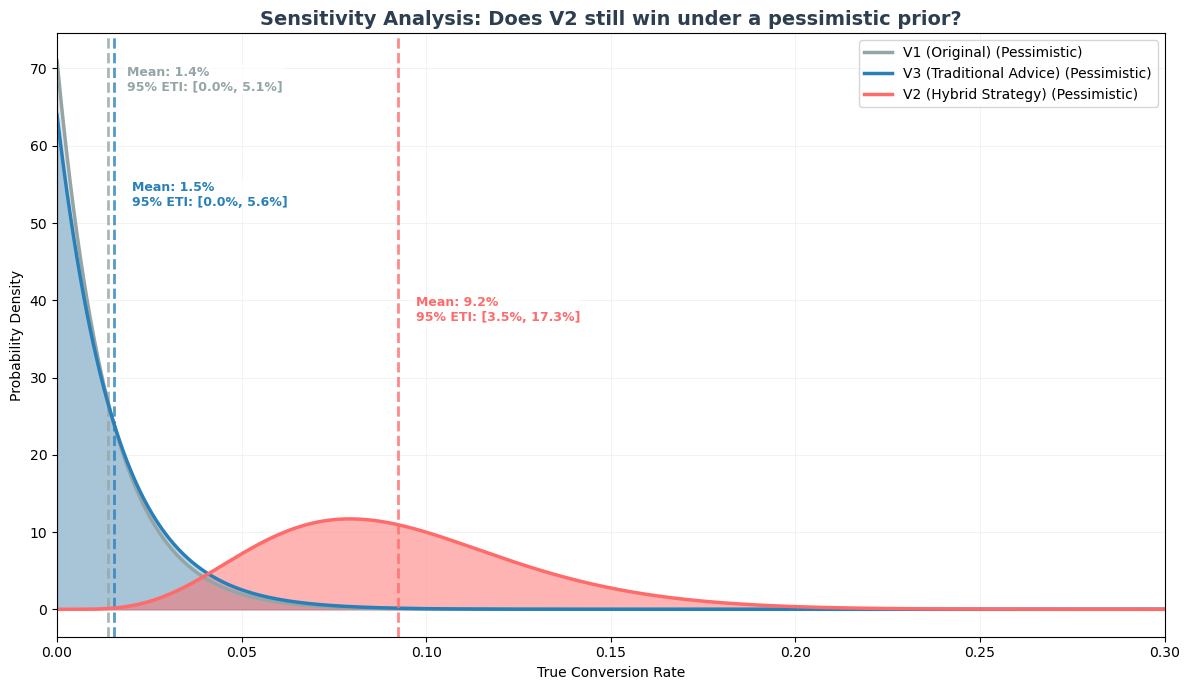

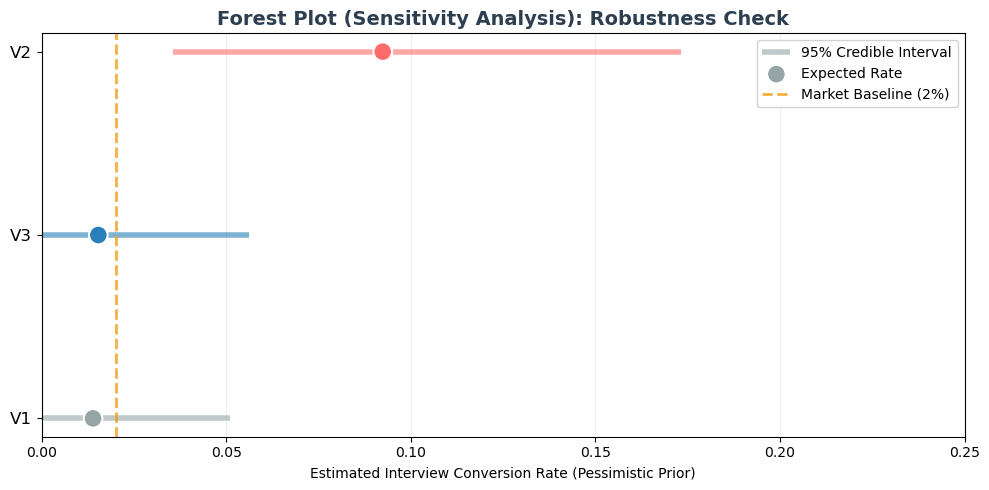

In [28]:
# ==========================================
# PART 9: Sensitivity Analysis (Pessimistic Prior)
# ==========================================
"""
Objective: Stress Test / Robustness Check.
Context:
- We simulate a "Hell Mode" scenario where the prior belief is extremely pessimistic (1 success vs 50 failures).
- This mimics a harsh recession environment or severe imposter syndrome.

Hypothesis:
- If V2 still shows significant dominance under this pessimistic prior, the strategy's success is robust
    (not just due to luck or optimistic assumptions).
Assumption: Extremely Pessimistic Prior Beta(1, 50).
    - "I assume a prior state of 1 success and 50 failures (approx. 1.96% success rate)."
        (Note: Strictly speaking, 1 in 50 applications would be Beta(1,49), but Beta(1,50) is slightly more pessimistic, making it an even stronger stress test.)
    - This tests if V2's success is just due to a lucky or optimistic prior.
Steps:
1. Visualize the Pessimistic Prior (to show how harsh it is).
2. Re-run Bayesian Update with this new prior.
3. Check if V2 still beats V3 and the Market Baseline.
"""
# 1. Define Pessimistic Prior
pessimistic_alpha, pessimistic_beta = 1, 50

print("\n" + "="*50)
print("SENSITIVITY ANALYSIS: PESSIMISTIC PRIOR Beta(1, 50)")
print("Assumption: 'A prior state of 1 success and 50 failures'")
print("="*50)

# 2. Visualize the Pessimistic Prior Distribution
prior_samples_pess = stats.beta(pessimistic_alpha, pessimistic_beta).rvs(n_sims)
sim_interviews_pess = stats.binom(n=50, p=prior_samples_pess).rvs(n_sims)

plt.figure(figsize=(10, 5))
plt.hist(sim_interviews_pess, bins=np.arange(-0.5, 10.5, 1), density=True,
         color=COLORS['Market'], edgecolor='white', alpha=0.6) # Use Market Orange
plt.title("Pessimistic Prior Predictive Distribution (Beta(1, 50))", fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel("Number of Interviews (out of 50 applications)")
plt.ylabel("Probability")
plt.axvline(1, color=COLORS['Panic'], linestyle='--', label='Expected: 1 Interview')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Re-calculate Posteriors
pessimistic_samples = {}
pessimistic_dists = {}

for key in plot_order:
    data = strategies[key]
    valid_n = data['n'] - data['german_req']
    successes = data['k']

    # Update
    post_alpha = pessimistic_alpha + successes
    post_beta = pessimistic_beta + (valid_n - successes)

    dist = stats.beta(post_alpha, post_beta)
    pessimistic_dists[key] = dist
    pessimistic_samples[key] = dist.rvs(n_samples)

    print(f"[{key}] Posterior: Beta({post_alpha}, {post_beta}) -> Mean: {dist.mean():.1%}")

# Compare V2 vs V3 (Pessimistic)
samples_v2_pess = pessimistic_samples['V2']
samples_v3_pess = pessimistic_samples['V3']

prob_v2_better_v3_pess = np.mean(samples_v2_pess > samples_v3_pess)
ci_v2_pess = np.percentile(samples_v2_pess, [2.5, 97.5])

print("-" * 30)
print(f"Even with a Pessimistic Prior:")
print(f"a) Probability that V2 > V3: {prob_v2_better_v3_pess:.4%}")
print(f"b) 95% Credible Interval for V2: [{ci_v2_pess[0]:.1%} - {ci_v2_pess[1]:.1%}]")

# Visualization (Noodle Plot - Pessimistic)
# Same posterior-predictive construction as Part 3: each line is a full
# Binomial draw from a rate sampled from the pessimistic posterior, and the
# envelope is the analytical Beta-Binomial 95% predictive interval. This way
# Part 3 and Part 9 report the same quantity under different priors — a fair
# apples-to-apples sensitivity check.

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Reproducible stress test
rng_pess = np.random.default_rng(222)

for ax, key in zip(axes, plot_order):
    data = strategies[key]
    color = data['color']

    # Pessimistic posterior parameters for this strategy
    valid_n = strategies[key]['n'] - strategies[key]['german_req']
    a_post = pessimistic_alpha + strategies[key]['k']
    b_post = pessimistic_beta + (valid_n - strategies[key]['k'])

    # A. Posterior-predictive noodles: rate ~ Beta, then y ~ Binomial(n, rate)
    simulated_rates = stats.beta(a_post, b_post).rvs(n_lines, random_state=rng_pess)
    for rate in simulated_rates:
        y_actual = rng_pess.binomial(x_future, rate)
        ax.plot(x_future, y_actual, color=color, alpha=0.05, linewidth=1.0)

    # B. Mean rate line
    mean_rate = a_post / (a_post + b_post)
    ax.plot(x_future, mean_rate * x_future, color=color, linewidth=3, linestyle='--',
            label=f"Avg Rate: {mean_rate:.1%}")

    # C. Analytical 95% Beta-Binomial Posterior Predictive Interval
    # (not rate × x_future — includes Binomial sampling noise, like Part 3)
    pp_lower = stats.betabinom.ppf(0.025, x_future, a_post, b_post)
    pp_upper = stats.betabinom.ppf(0.975, x_future, a_post, b_post)
    ax.fill_between(x_future, pp_lower, pp_upper,
                    color=color, alpha=0.15, label="95% Posterior Predictive Interval")

    ax.set_title(data['label'] + " (Pessimistic)", fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_xlabel("Future Applications (English Only)", fontsize=11)
    if key == plot_order[0]:
        ax.set_ylabel("Expected Interviews", fontsize=12)

    ax.axhline(10, color=COLORS['Target'], linestyle=':', linewidth=2, alpha=0.8)
    ax.text(0, 10.5, "Target (10 Interviews)", color=COLORS['Target'], fontsize=9, fontweight='bold', alpha=0.9)

    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 25)

plt.suptitle("Stress Test: Pessimistic Posterior Predictive Simulation", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Visualization (KDE)
plt.figure(figsize=(12, 7))

x_grid = np.linspace(0, 0.30, 1000)

# Fix y-limits BEFORE the loop so text positions are consistent
Y_MAX_PESS = 60
plt.ylim(0, Y_MAX_PESS)

for key in plot_order:
    dist = pessimistic_dists[key]
    color = strategies[key]['color']
    label = strategies[key]['short_label'] + " (Pessimistic)"

    # 1. Plot analytical Beta PDF (exact, no bandwidth / boundary artifacts)
    pdf_y = dist.pdf(x_grid)
    plt.plot(x_grid, pdf_y, color=color, linewidth=2.5, label=label)
    plt.fill_between(x_grid, pdf_y, color=color,
                     alpha=0.3 if key != 'V2' else 0.5)

    # 2. Stats: mean + 95% equal-tailed credible interval (from dist, not samples,
    # so we get the true posterior quantiles rather than MC estimates)
    avg = dist.mean()
    ci_lo, ci_hi = dist.ppf([0.025, 0.975])

    # 3. Line for mean
    plt.axvline(avg, color=color, linestyle='--', linewidth=2, alpha=0.8)

    # 4. Text (staggered so labels don't overlap)
    if key == 'V1':
        y_pos_factor = 0.90
    elif key == 'V3':
        y_pos_factor = 0.70
    else:
        y_pos_factor = 0.50
    y_pos = Y_MAX_PESS * y_pos_factor

    plt.text(avg + 0.005, y_pos,
             f"Mean: {avg:.1%}\n95% ETI: [{ci_lo:.1%}, {ci_hi:.1%}]",
             color=color, fontweight='bold', fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

plt.title("Sensitivity Analysis: Does V2 still win under a pessimistic prior?",
          fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel("True Conversion Rate")
plt.ylabel("Probability Density")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.xlim(0, 0.30)
plt.tight_layout()
plt.show()

# Visualization (Forest Plot)
plt.figure(figsize=(10, 5))

means_pess = []
ci_lower_pess = []
ci_upper_pess = []
colors_pess = []
labels_pess = []

for key in plot_order:
    samples = pessimistic_samples[key]
    means_pess.append(np.mean(samples))
    # Consistent 95% CI
    ci = np.percentile(samples, [2.5, 97.5])
    ci_lower_pess.append(ci[0])
    ci_upper_pess.append(ci[1])
    colors_pess.append(strategies[key]['color'])
    labels_pess.append(key)

y_pos = np.arange(len(labels_pess))
plt.hlines(y_pos, ci_lower_pess, ci_upper_pess, color=colors_pess, linewidth=4, alpha=0.6, label='95% Credible Interval')
plt.scatter(means_pess, y_pos, color=colors_pess, s=180, zorder=3, edgecolors='white', linewidth=1.5, label='Expected Rate')

plt.yticks(y_pos, labels_pess, fontsize=12)
plt.xlabel("Estimated Interview Conversion Rate (Pessimistic Prior)")
plt.title("Forest Plot (Sensitivity Analysis): Robustness Check", fontsize=14, fontweight='bold', color='#2c3e50')

# Add Market Baseline using Global Constant
plt.axvline(MARKET_BASELINE, color=COLORS['Market'], linestyle='--', linewidth=2, alpha=0.8, label=f'Market Baseline ({MARKET_BASELINE:.0%})')

# Auto-scale X-axis
max_val = max(ci_upper_pess)
plt.xlim(0, max(0.25, max_val * 1.2))

plt.grid(axis='x', alpha=0.3)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


In [29]:
# ==========================================
# PART 10: Statistical Validation (Robustness Check)
# ==========================================
"""
Objective: rigorous statistical testing to answer:
1. "Is it just luck?" (Binomial Test)
2. "What is the worst-case skill level?" (Bayesian Lower Bound)
"""

print("="*60)
print("STATISTICAL VALIDATION: Is V2 really better, or just lucky?")
print("="*60)

# --- 1A. The "Luck" Test (Frequentist Approach: Binomial Test) ---
# Hypothesis: V2's true skill is actually just 2% (Market Baseline).
# Question: What is the probability of getting >= k interviews in n apps purely by chance?
# Derive n_trials and k_successes from strategies dict so this stays in sync if data changes.
n_trials = strategies['V2']['n'] - strategies['V2']['german_req']
k_successes = strategies['V2']['k']
p_baseline = MARKET_BASELINE  # 2% Market Baseline (single source of truth from Cell 0)

# Calculate P-value (Survival Function: Probability of X >= k)
p_value_luck = stats.binom.sf(k_successes - 1, n_trials, p_baseline)

print(f"Test 1A: Binomial Test (H0: Market Assumption = 2%)")
print(f"   - Observation: {k_successes} successes in {n_trials} trials")
print(f"   - Probability of this happening by pure luck: {p_value_luck:.8f} ({p_value_luck*100:.5f}%)")
if p_value_luck < 0.01:
    print("   -> RESULT: Highly Significant (Reject H0).")
else:
    print("   -> RESULT: Not Significant.")



# --- 1B. V2 vs. Pooled Control (V1 + V3) under Jeffreys Prior
"""
Question: Is V2's performance distinguishable from the pooled V1+V3 baseline,
without borrowing any information from the other test?

Method: Independent Bayesian posteriors on both arms using the same
objective Jeffreys prior Beta(0.5, 0.5). Compare at the posterior level.
No data is shared between the two posteriors, so there is no circularity.

Why Jeffreys: it's the uninformative reference prior for binomial
proportions, invariant under reparametrization, and treats both arms
symmetrically — unlike using V1+V3's data as a prior for V2.
"""

# ---- Pool the control arms ----
pooled_k = strategies['V1']['k'] + strategies['V3']['k']                          # 0
pooled_n = ((strategies['V1']['n'] - strategies['V1']['german_req']) +
            (strategies['V3']['n'] - strategies['V3']['german_req']))             # 35
v2_k     = strategies['V2']['k']                                                  # 5
v2_n     = strategies['V2']['n'] - strategies['V2']['german_req']                 # 14

# ---- Independent Jeffreys posteriors ----
jeff_a, jeff_b = 0.5, 0.5

pooled_post = stats.beta(jeff_a + pooled_k, jeff_b + (pooled_n - pooled_k))
v2_post     = stats.beta(jeff_a + v2_k,     jeff_b + (v2_n - v2_k))

pooled_mean = pooled_post.mean()
v2_mean     = v2_post.mean()

pooled_ci = pooled_post.ppf([0.025, 0.975])
v2_ci     = v2_post.ppf([0.025, 0.975])

# ---- Posterior-level comparison ----
rng_1b = np.random.default_rng(222)
n_mc = 100_000
pooled_samples = pooled_post.rvs(n_mc, random_state=rng_1b)
v2_samples     = v2_post.rvs(n_mc, random_state=rng_1b)

diff_samples = v2_samples - pooled_samples
prob_v2_beats_pooled = (v2_samples > pooled_samples).mean()
diff_mean = diff_samples.mean()
diff_ci   = np.percentile(diff_samples, [2.5, 97.5])

print("=" * 60)
print("TEST 1B — V2 vs. Pooled Control (Jeffreys Prior, Independent Posteriors)")
print(f"Pooled (V1+V3):  {pooled_k}/{pooled_n}  "
      f"→ Beta({jeff_a + pooled_k}, {jeff_b + (pooled_n - pooled_k)})")
print(f"  mean = {pooled_mean:.2%}   95% ETI = [{pooled_ci[0]:.2%}, {pooled_ci[1]:.2%}]")
print(f"V2:              {v2_k}/{v2_n}   "
      f"→ Beta({jeff_a + v2_k}, {jeff_b + (v2_n - v2_k)})")
print(f"  mean = {v2_mean:.2%}   95% ETI = [{v2_ci[0]:.2%}, {v2_ci[1]:.2%}]")
print("-" * 60)
print(f"P(V2 > Pooled Control) = {prob_v2_beats_pooled:.4%}")
print(f"Posterior mean lift    = +{diff_mean:.1%}")
print(f"95% ETI for lift       = [{diff_ci[0]:.1%}, {diff_ci[1]:.1%}]")
print("=" * 60)

# --- 2. The "Skill Floor" Test (Bayesian Approach: Credible Interval) ---
# Question: Even if I was lucky, what is the guaranteed minimum skill level?
# We calculate the 2.5th percentile of V2's posterior (lower bound of 95% CI).
# Reuse the posterior built in Cell 2 — single source of truth.
v2_dist = strategies['V2']['posterior_dist']
skill_floor = v2_dist.ppf(0.025)
mean_skill = v2_dist.mean()

print(f"Test 2: Bayesian Lower Bound (The 'Skill Floor')")
print(f"   - Estimated Mean Skill: {mean_skill:.1%}")
print(f"   - 95% Credible Interval Lower Bound: {skill_floor:.1%}")
print(f"   -> INTERPRETATION: There is a 97.5% probability that the true V2 conversion rate is at least {skill_floor:.1%}.")
print(f"      (This is significantly higher than the Market Baseline of {p_baseline:.1%})")

print("="*60)

STATISTICAL VALIDATION: Is V2 really better, or just lucky?
Test 1A: Binomial Test (H0: Market Assumption = 2%)
   - Observation: 5 successes in 14 trials
   - Probability of this happening by pure luck: 0.00000551 (0.00055%)
   -> RESULT: Highly Significant (Reject H0).
TEST 1B — V2 vs. Pooled Control (Jeffreys Prior, Independent Posteriors)
Pooled (V1+V3):  0/35  → Beta(0.5, 35.5)
  mean = 1.39%   95% ETI = [0.00%, 6.88%]
V2:              5/14   → Beta(5.5, 9.5)
  mean = 36.67%   95% ETI = [15.15%, 61.55%]
------------------------------------------------------------
P(V2 > Pooled Control) = 99.9930%
Posterior mean lift    = +35.3%
95% ETI for lift       = [13.3%, 60.3%]
Test 2: Bayesian Lower Bound (The 'Skill Floor')
   - Estimated Mean Skill: 37.5%
   - 95% Credible Interval Lower Bound: 16.3%
   -> INTERPRETATION: There is a 97.5% probability that the true V2 conversion rate is at least 16.3%.
      (This is significantly higher than the Market Baseline of 2.0%)


ALPHA ANALYSIS: Comparing against Market Expectations
Observed Conversion Rate (V2): 35.7%
----------------------------------------
[Scenario A] Standard Candidate (Native/Tech or Business Background)
   - Market Expectation: 10.0%
   - Performance Lift:   3.6x
   - Alpha (Excess Return): +25.7%
----------------------------------------
[Scenario B] My Profile (A1 German/Pivot/Cold Apply)
   - Market Expectation: 2.0%
   - Performance Lift:   17.9x  <-- The true power of V2
   - Alpha (Excess Return): +33.7%


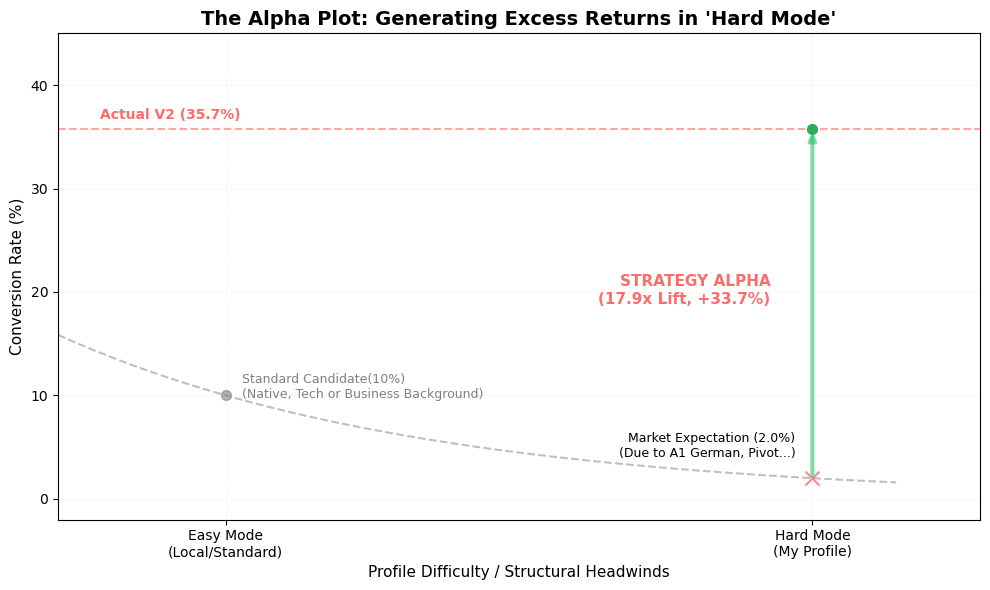

In [30]:
# ==========================================
# PART 11: The "Alpha" Analysis (Risk-Adjusted Performance)
# ==========================================
"""
Objective: Frame V2's performance using a finance/management "alpha vs benchmark"
lens — quantifying how the observed rate compares to a stylized market-expectation curve.

⚠️  NARRATIVE VISUALIZATION — NOT STATISTICAL INFERENCE  ⚠️

What is REAL (empirical):
  - V2's observed conversion rate: k / valid_n = 5 / 14 ≈ 35.7%
  - The 2% baseline: inherited from Part 9's Pessimistic Prior mean, used as a
    stress-test proxy for "Hell Mode" structural headwinds
    (Recession + A1 German + Career Pivot).

What is ILLUSTRATIVE (constructed for visualization only — not fitted or measured):
  - MARKET_BASE_RATE (15.85%): a hypothetical "flawless candidate" anchor.
  - DIFFICULTY_DECAY (0.23): a chosen decay constant (NOT fitted to data).
  - Difficulty scores (Local=2, My Profile=9): subjective positional anchors.
  - The decay curve y = 15.85 * exp(-0.23 * x) is a METAPHOR for "market gravity,"
    not an estimated model of any real population.

The "Lift" multiplier borrows the financial concept of alpha — excess return over
a benchmark. Here the benchmark is a constructed market-expectation curve, not a
measured population rate. Interpret this section as a cross-disciplinary framing
device (finance/management vocabulary) layered on top of one real data point
(35.7%) and one stress-test anchor (2%), NOT as a Bayesian or frequentist
inference about population parameters.
"""

print("="*60)
print("ALPHA ANALYSIS: Comparing against Market Expectations")
print("="*60)

# 1. Define Expectations (Hypothetical Market Data)
# Standard: Native speaker, relevant degree, warm economy
MARKET_BASE_RATE = 15.85  # Theoretical interview rate (~15.85%) for a flawless candidate (Difficulty=0)
DIFFICULTY_DECAY = 0.23   # Decay factor calculated to ensure the curve hits ~2% at difficulty level 9
expected_rate_standard = 0.1  # 10%

# User (Hard Mode): Non-native, career pivot, recession, cold apply
# We use the V1/V3 results as a proxy for the true market expectation for this profile
# Dynamic reference from Part 9's pessimistic prior mean (approx 2%)
expected_rate_user = MARKET_BASELINE

# 2. Actual Performance (V2)
actual_rate_v2 = strategies['V2']['k'] / (strategies['V2']['n'] - strategies['V2']['german_req'])

# 3. Calculate Lift (Multiple) & Alpha (Absolute Diff)
lift_standard = actual_rate_v2 / expected_rate_standard
lift_user = actual_rate_v2 / expected_rate_user

alpha_standard = actual_rate_v2 - expected_rate_standard
alpha_user = actual_rate_v2 - expected_rate_user

print(f"Observed Conversion Rate (V2): {actual_rate_v2:.1%}")
print("-" * 40)
print(f"[Scenario A] Standard Candidate (Native/Tech or Business Background)")
print(f"   - Market Expectation: {expected_rate_standard:.1%}")
print(f"   - Performance Lift:   {lift_standard:.1f}x")
print(f"   - Alpha (Excess Return): +{alpha_standard:.1%}")
print("-" * 40)
print(f"[Scenario B] My Profile (A1 German/Pivot/Cold Apply)")
print(f"   - Market Expectation: {expected_rate_user:.1%}")
print(f"   - Performance Lift:   {lift_user:.1f}x  <-- The true power of V2")
print(f"   - Alpha (Excess Return): +{alpha_user:.1%}")
print("="*60)

# Visualization
plt.figure(figsize=(10, 6))

# 1. Define Data Points
# Format: (Difficulty Score 0-10, Conversion Rate %)
# Difficulty: 0 = Easy (Local/Tech), 10 = Hard (A1/Pivot/NoPhoto)

# Scenario 1: The "Standard" Local Candidate
# Low difficulty, decent return
x_local = 2
y_local = 10

# Scenario 2: You (Without Strategy / V1 & V3)
# High difficulty, market expects 0% return
x_you_exp = 9
y_you_exp = expected_rate_user * 100 # Convert to percentage

# Scenario 3: You (With V2 Strategy)
# High difficulty, anomalies return
x_you_act = 9
y_you_act = actual_rate_v2 * 100 # Convert to percentage

# 2. Plot the "Market Gravity" (Expected Decay Curve)
# As difficulty increases, expected return drops exponentially
x_range = np.linspace(0, 10, 100)
y_market = MARKET_BASE_RATE * np.exp(-DIFFICULTY_DECAY * x_range) # Decay function


plt.plot(x_range, y_market, color='gray', linestyle='--', alpha=0.5, label='Market Expectation')

# 3. Plot the Candidates
plt.scatter(x_local, y_local, color='gray', s=50, alpha=0.6, label='Standard Candidate')
plt.scatter(x_you_exp, y_you_exp, color=COLORS['V2'], s=100, alpha=0.8, marker='x', label='My Profile (Expected / V1&V3)')
plt.scatter(x_you_act, y_you_act, color='#27ae60', s=50, zorder=5, label='My Profile (Actual / V2)')

# 4. Draw the "Alpha" Arrow (The Lift)
plt.annotate('', xy=(x_you_act, y_you_act), xytext=(x_you_exp, y_you_exp),
             arrowprops=dict(arrowstyle='-|>', color='#2ecc71', lw=3, ls='-', alpha=0.6))

# 5. Add Annotations
plt.text(x_local+0.2, y_local+0.8, f"Standard Candidate({y_local}%)\n(Native, Tech or Business Background)", fontsize=9, color='gray', va='center')
plt.text(x_you_exp-0.2, y_you_exp+2, f"Market Expectation ({y_you_exp:.1f}%)\n(Due to A1 German, Pivot...)", fontsize=9, color='black', ha='right') # Added percentage

# Highlight the Alpha
plt.text(x_you_act-0.5, (y_you_act + y_you_exp)/2, f"STRATEGY ALPHA\n({y_you_act/y_you_exp:.1f}x Lift, +{alpha_user:.1%})",
         fontsize=11, fontweight='bold', color=COLORS['V2'], ha='right')

# 6. Add 36% Horizontal Line
plt.axhline(y=y_you_act, color=COLORS['V2'], linestyle='--', alpha=0.6)
plt.text(0.5, y_you_act + 1, f"Actual V2 ({y_you_act:.1f}%)", color=COLORS['V2'], fontweight='bold')

# 7. Styling
plt.title("The Alpha Plot: Generating Excess Returns in 'Hard Mode'", fontsize=14, fontweight='bold')
plt.xlabel("Profile Difficulty / Structural Headwinds", fontsize=11)
plt.ylabel("Conversion Rate (%)", fontsize=11)
plt.xlim(0, 11)
plt.ylim(-2, 45)
plt.grid(True, alpha=0.2, linestyle='--')

# Custom X-axis labels
plt.xticks([2, 9], ["Easy Mode\n(Local/Standard)", "Hard Mode\n(My Profile)"])

plt.tight_layout()
plt.show()

In [31]:
# ==========================================
# PART 12: Final Verdict
# ==========================================
mean_v2 = np.mean(strategies['V2']['samples'])
mean_v1 = np.mean(strategies['V1']['samples'])
mean_v3 = np.mean(strategies['V3']['samples'])
mean_v2_pessimistic = np.mean(pessimistic_samples['V2'])

print("="*60)
print("FINAL VERDICT (EXECUTIVE SUMMARY)")
print("="*60)
print(f"1. STRATEGY WINNER: V2 (Hybrid Strategy) is the clear winner.")
print(f"   - Posterior Mean Conversion Rate: {mean_v2:.1%} (vs. {mean_v1:.1%} for V1, {mean_v3:.1%} for V3).")
print(f"   - It is the ONLY strategy that generated interviews.")
print("-" * 60)
print(f"2. CRITICAL LESSON: The 'Lag Effect' (Patience > Panic)")
print(f"   - The switch to V3 (Traditional) was a mistake caused by anxiety.")
print(f"   - Data shows V2 was working, but recruiter latency caused a false negative.")
print(f"   - 100% of results arrived AFTER the panic switch.")
print("-" * 60)
print(f"3. MARKET INSIGHT: The Limits of Conventional Advice")
print(f"   - Adhering strictly to traditional norms (V3) yielded baseline results.")
print(f"   - V2 generated significant 'Alpha' ({lift_user:.1f}x Lift), showing that")
print(f"     strategic differentiation outweighs conformity.")
print("-" * 60)
print(f"4. STATISTICAL VALIDATION:")
print(f"   - Luck Excluded: Binomial test rejects the 'pure luck' hypothesis (p={p_value_luck:.2e}).")
print(f"   - Skill Floor: 97.5% posterior probability that V2's true rate exceeds {skill_floor:.1%}.")
print(f"   - Robustness: Even under pessimistic priors, V2 maintains a {mean_v2_pessimistic:.1%} success rate.")
print("="*60)

FINAL VERDICT (EXECUTIVE SUMMARY)
1. STRATEGY WINNER: V2 (Hybrid Strategy) is the clear winner.
   - Posterior Mean Conversion Rate: 37.5% (vs. 4.3% for V1, 6.2% for V3).
   - It is the ONLY strategy that generated interviews.
------------------------------------------------------------
2. CRITICAL LESSON: The 'Lag Effect' (Patience > Panic)
   - The switch to V3 (Traditional) was a mistake caused by anxiety.
   - Data shows V2 was working, but recruiter latency caused a false negative.
   - 100% of results arrived AFTER the panic switch.
------------------------------------------------------------
3. MARKET INSIGHT: The Limits of Conventional Advice
   - Adhering strictly to traditional norms (V3) yielded baseline results.
   - V2 generated significant 'Alpha' (17.9x Lift), showing that
     strategic differentiation outweighs conformity.
------------------------------------------------------------
4. STATISTICAL VALIDATION:
   - Luck Excluded: Binomial test rejects the 'pure luck' hy